In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Name":["Alice","Bob","Claire", "Aman", "Riya",
            "Sneha", "Arjun","Priya","Rohan","Neha",
            "karan","Pooja","Vikas","Anjali","Ravi"],
    "Age":[25,30,27, 18,19,
           18, 21,22,19,23,
           21,25,30,27, 17],
    "Gender":["Female","Male","Female","Male","Male",
              "Female","Male","Female","Male","Male",
              "Female","Male","Female","Male","Male"],
    "Study_Hours":[2,4,5,1,6,
                   7,2,5,2,6,
                   8,3,7,1, 5],
    "Attenance":[90,75, 70,65,70,
                 90,75, 70,65,70,
                 90,75, 70,65,70],
    "Marks":[65,78,85,20,92,
             88,38,85,45, 65,
             95,33,85,25, 75]

}
df = pd.DataFrame(data)

In [4]:
def performance(marks):
    if marks >= 85:
        return 'Excellent'
    elif marks >= 65:
        return 'Good'
    elif marks >= 35:
        return 'Average'
    else:
        return 'Needs Improvement'

df['Performance_Category'] = df['Marks'].apply(performance)

In [5]:
#Convert Age from numerical to categorical
bins = [0, 19, 22, 100]
labels = ["Teen", "Young Adult", "Adult"]

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

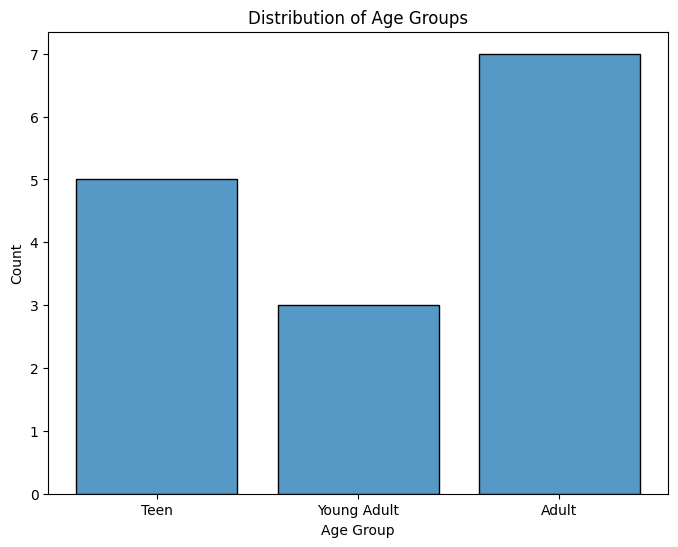

In [6]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Age_Group', shrink=0.8)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

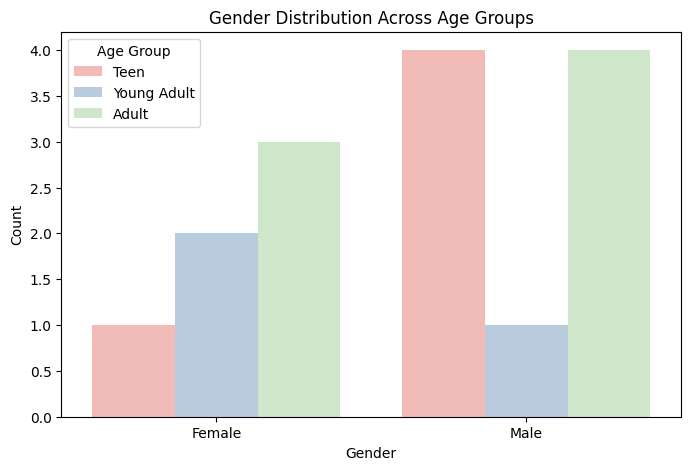

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Age_Group', palette='Pastel1')
plt.title('Gender Distribution Across Age Groups')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.show()

/tmp/ipykernel_715/1025328583.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Group', palette='Set2')


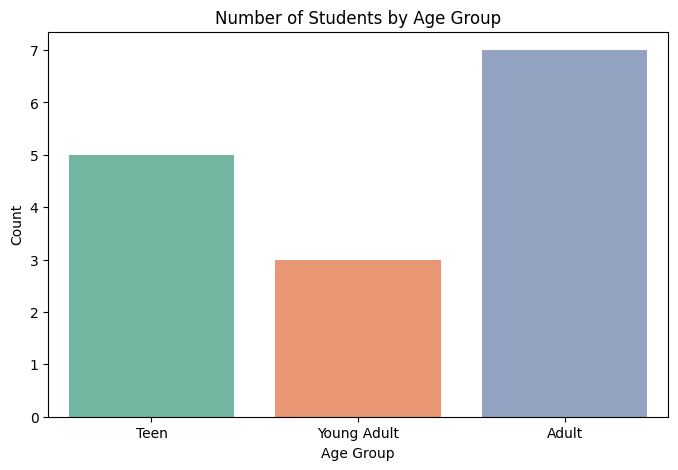

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Group', palette='Set2')
plt.title('Number of Students by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

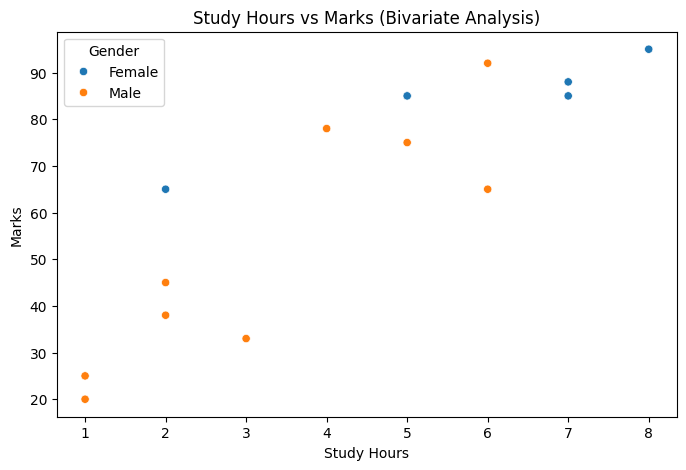

In [9]:
#Bivariate analysis
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Study_Hours', y='Marks', hue='Gender')
plt.title('Study Hours vs Marks (Bivariate Analysis)')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.show()

In [10]:
# Correlation between Two variables
correlation_matrix = df[['Study_Hours', 'Marks']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
             Study_Hours     Marks
Study_Hours     1.000000  0.874658
Marks           0.874658  1.000000


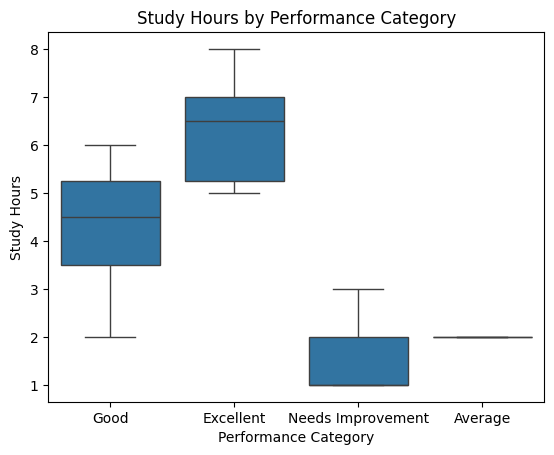

In [11]:
# Numerical Vs. Categorical
sns.boxplot(data=df, x='Performance_Category', y='Study_Hours')
plt.title('Study Hours by Performance Category')
plt.xlabel('Performance Category')
plt.ylabel('Study Hours')
plt.show()

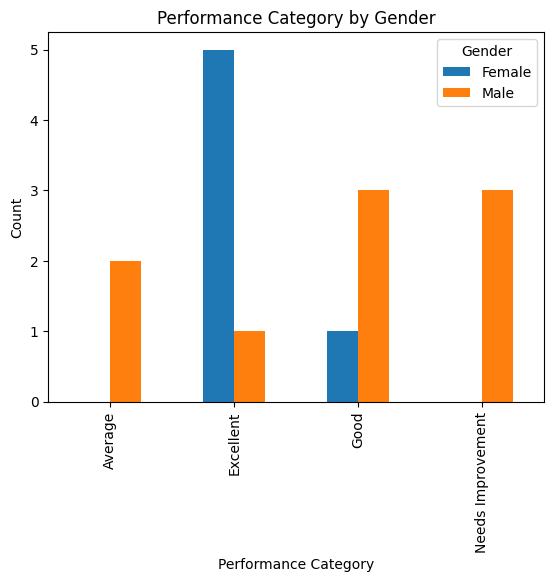

In [12]:
pd.crosstab(df['Performance_Category'], df['Gender']).plot(kind='bar')
plt.title('Performance Category by Gender')
plt.xlabel('Performance Category')
plt.ylabel('Count')
plt.show()

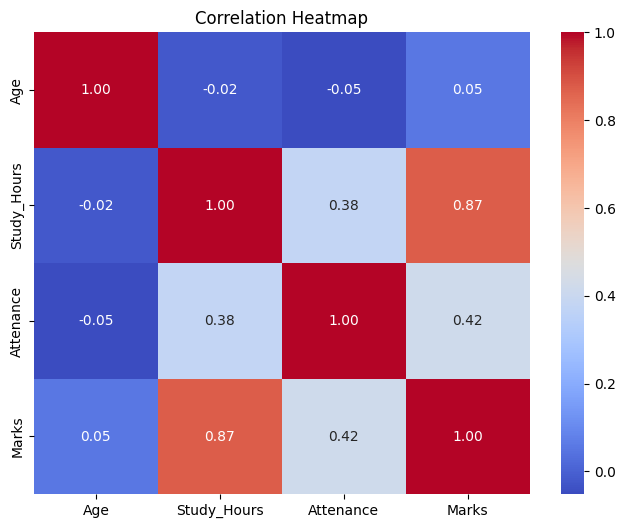

In [13]:
# Correlation heat map
correlation_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()